In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.preprocessing import KFold as MiniKFold
from minilearn.classifiers import LogisticRegression as MiniLR

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

#load saved data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

#seperate featuer and labels
feature_col = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[feature_col].values
y_train = train_df['emotion'].values

X_test = test_df[feature_col].values
y_test = test_df['emotion'].values

#fix featul label space issue
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

#combine train and test for cross validation.
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

print(f"Full dataset: {X_all.shape}")
print(f"Classes {np.unique(y_all)}")

Full dataset: (2452, 112)
Classes ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [6]:
#test Minilearn Kfold
print("Testing Minilearn KFold Cross Validation")
mini_kf = MiniKFold(n_splits=5, shuffle=True, random_state=42)
mini_lr = MiniLR(learning_rate=0.01, n_iterations=1000)

mini_cv_scores = []

for fold, (train_idx, test_idx) in enumerate(mini_kf.split(X_all, y_all)):
    X_fold_train, X_fold_test = X_all[train_idx], X_all[test_idx]
    y_fold_train, y_fold_test = y_all[train_idx], y_all[test_idx]

    mini_lr.fit(X_fold_train, y_fold_train)
    score = mini_lr.score(X_fold_test, y_fold_test)
    mini_cv_scores.append(score)
    print(f"Fold {fold+1} Accuracy: {score:.4f}")
print(f"\nMinilearn KFold Mean Accuracy: {np.mean(mini_cv_scores):.4f}")
print(f"Minilearn kFold std: {np.std(mini_cv_scores):.4f}")


Testing Minilearn KFold Cross Validation
Fold 1 Accuracy: 0.5906
Fold 2 Accuracy: 0.5540
Fold 3 Accuracy: 0.5898
Fold 4 Accuracy: 0.5837
Fold 5 Accuracy: 0.5469

Minilearn KFold Mean Accuracy: 0.5730
Minilearn kFold std: 0.0187


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': SklearnLR(max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN k=5': KNeighborsClassifier(n_neighbors=5),
    'SVM RBF (C=10)': SVC(kernel='rbf', C=10, gamma='scale'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}
results = {}

for name, model in models.items():
    print(f"Cross Validating {name}")
    scores = cross_val_score(model, X_all, y_all, cv=skf, scoring='accuracy')
    results[name] = {
        'mean': np.mean(scores),
        'std': np.std(scores)
    }
    print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Cross Validating Logistic Regression
Logistic Regression: 0.6452 (+/- 0.0115)
Cross Validating Gaussian Naive Bayes
Gaussian Naive Bayes: 0.3834 (+/- 0.0174)
Cross Validating KNN k=5
KNN k=5: 0.5526 (+/- 0.0207)
Cross Validating SVM RBF (C=10)
SVM RBF (C=10): 0.7357 (+/- 0.0160)
Cross Validating Decision Tree
Decision Tree: 0.3650 (+/- 0.0160)
Cross Validating Random Forest
Random Forest: 0.6150 (+/- 0.0205)
Cross Validating AdaBoost
AdaBoost: 0.3993 (+/- 0.0293)


In [8]:
# building comparison table 
comparison_data = {
    'Model': [],
    'CV Mean Accuracy': [],
    'CV Std': [],
}

for name, result in results.items():
    comparison_data['Model'].append(name)
    comparison_data["CV Mean Accuracy"].append(round(result['mean'], 4))
    comparison_data["CV Std"].append(round(result['std'],4))

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values("CV Mean Accuracy", ascending=False)
comparison_df = comparison_df.reset_index(drop=True)
print(comparison_df.to_string(index=False))



               Model  CV Mean Accuracy  CV Std
      SVM RBF (C=10)            0.7357  0.0160
 Logistic Regression            0.6452  0.0115
       Random Forest            0.6150  0.0205
             KNN k=5            0.5526  0.0207
            AdaBoost            0.3993  0.0293
Gaussian Naive Bayes            0.3834  0.0174
       Decision Tree            0.3650  0.0160


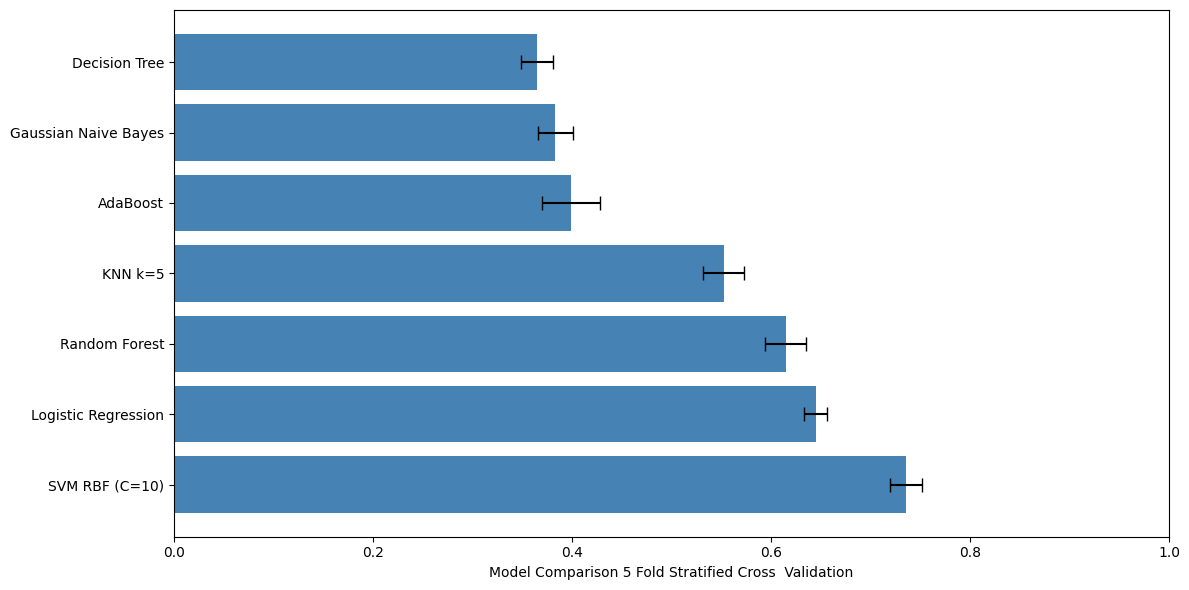

In [9]:
#visualization model comparison
plt.figure(figsize=(12,6))
plt.barh(comparison_df['Model'], comparison_df['CV Mean Accuracy'], xerr=comparison_df["CV Std"], capsize=5, color='steelblue')
plt.xlabel("Model Comparison 5 Fold Stratified Cross  Validation")
plt.xlim(0,1)
plt.tight_layout()
plt.show()


In [ ]:
#hyperparamters tuning for random forest
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5,10,15,None],
    'min_samples_split':[2,5,10],
    'max_features': ['sqrt', 'log2']
}
print("Running RandomizedSearch from Random Forest")
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=1
)

random_search.fit(X_all, y_all)

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV Accuracy: {random_search.best_score_:.4f}")
